# Лабораторная работа 3 — Сегментация дорожных знаков и трекинг

**Цель:** Обучить модель сегментации на наборе Russian road signs (sign_dataset), оценить метрики на валидации и на отснятых видео, запустить два алгоритма трекинга и посчитать ID Switches.

In [2]:
# Установка зависимостей (выполнить один раз в терминале или раскомментировать ниже)
# !pip install ultralytics opencv-python pycocotools scipy tqdm
# На Mac (Apple Silicon) PyTorch автоматически использует MPS (Metal GPU) — обучение и инференс ускорятся.

# Для раздела с видео: создайте папку videos/ и положите туда 3+ видео по 30+ сек (около ИТМО или в узнаваемых местах).

## 1. Подготовка данных: конвертация sign_dataset (VIA) в COCO и загрузка

Путь к данным: `sign_dataset/train`, `sign_dataset/val` с файлами `via_region_data.json`.

In [3]:
import os
import json
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.patches as patches

def get_device():
    try:
        import torch
        if torch.backends.mps.is_available():
            return "mps"
        if torch.cuda.is_available():
            return 0
    except Exception:
        pass
    return "cpu"

DEVICE = get_device()
print("Устройство:", DEVICE)

DATA_DIR = os.path.join(os.getcwd(), "sign_dataset")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = "sign_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
print("DATA_DIR:", DATA_DIR)
print("Train exists:", os.path.isdir(TRAIN_DIR))
print("Val exists:", os.path.isdir(VAL_DIR))

Устройство: mps
DATA_DIR: /Users/ru.nazarov/Documents/university/sem8/computer_vision/lab3/sign_dataset
Train exists: True
Val exists: True


In [4]:
def patch_to_coords(figure):
    path = figure.get_path()
    transform = figure.get_transform()
    newpath = transform.transform_path(path)
    points = newpath.to_polygons()[0]
    return [float(c) for point in points for c in point]

def circle_to_polygon(region):
    cx, cy, r = region["cx"], region["cy"], region["r"]
    polygon = patch_to_coords(patches.Circle(xy=(cx, cy), radius=r))
    return polygon

def ellipse_to_polygon(region):
    cx, cy, rx, ry = region["cx"], region["cy"], region["rx"], region["ry"]
    w, h = 2 * rx, 2 * ry
    polygon = patch_to_coords(patches.Ellipse(xy=(cx, cy), width=w, height=h))
    return polygon

def rect_to_polygon(region):
    x, y, w, h = region["x"], region["y"], region["width"], region["height"]
    return [x, y, x, y + h, x + w, y + h, x + w, y, x, y]

def to_polygon(region, figure):
    if figure == "rect":
        return rect_to_polygon(region)
    if figure == "circle":
        return circle_to_polygon(region)
    if figure == "ellipse":
        return ellipse_to_polygon(region)
    xs, ys = region["all_points_x"], region["all_points_y"]
    return [p for point in zip(xs, ys) for p in point]

def parse_region(region):
    if "shape_attributes" not in region or region.get("region_attributes", {}).get("name") != "road sign":
        return None
    region = region["shape_attributes"]
    return to_polygon(region, region["name"])

def via_to_coco(ann_path, image_folder):
    with open(ann_path, "r", encoding="utf-8") as f:
        ann = json.load(f)
    images, annots, obj_id = [], [], 0
    for image_id, image_ann in tqdm(ann.items(), desc="VIA→COCO"):
        fname = image_ann["filename"]
        impath = os.path.join(image_folder, fname)
        if not os.path.isfile(impath):
            continue
        img = Image.open(impath)
        w, h = img.size
        images.append({"id": image_id, "file_name": fname, "width": w, "height": h})
        for region in (image_ann.get("regions") or {}).values():
            poly = parse_region(region)
            if poly is None:
                continue
            xs, ys = poly[::2], poly[1::2]
            x, y, w, h = min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)
            annots.append({
                "id": obj_id, "image_id": image_id, "area": w * h,
                "bbox": [x, y, w, h], "segmentation": [poly], "category_id": 0, "iscrowd": 0
            })
            obj_id += 1
    return {"images": images, "annotations": annots, "categories": [{"id": 0, "name": "road_sign"}]}

In [5]:
# Собираем COCO для train и val
def build_coco(ann_path, image_folder):
    with open(ann_path, "r", encoding="utf-8") as f:
        ann = json.load(f)
    images, annots, obj_id, idx = [], [], 0, 0
    for image_ann in tqdm(ann.values(), desc="COCO"):
        fname = image_ann["filename"]
        impath = os.path.join(image_folder, fname)
        if not os.path.isfile(impath):
            continue
        img = Image.open(impath)
        w, h = img.size
        images.append({"id": idx, "file_name": fname, "width": w, "height": h})
        for region in (image_ann.get("regions") or {}).values():
            poly = parse_region(region)
            if poly is None:
                continue
            xs, ys = poly[::2], poly[1::2]
            x, y, wb, hb = min(xs), min(ys), max(xs) - min(xs), max(ys) - min(ys)
            annots.append({
                "id": obj_id, "image_id": idx, "area": wb * hb,
                "bbox": [x, y, wb, hb], "segmentation": [poly], "category_id": 0, "iscrowd": 0
            })
            obj_id += 1
        idx += 1
    return {"images": images, "annotations": annots, "categories": [{"id": 0, "name": "road_sign"}]}

train_ann = os.path.join(TRAIN_DIR, "via_region_data.json")
val_ann = os.path.join(VAL_DIR, "via_region_data.json")
coco_train = build_coco(train_ann, TRAIN_DIR) if os.path.isfile(train_ann) else None
coco_val = build_coco(val_ann, VAL_DIR) if os.path.isfile(val_ann) else None
if coco_train:
    with open("coco_train.json", "w", encoding="utf-8") as f:
        json.dump(coco_train, f, ensure_ascii=False)
if coco_val:
    with open("coco_val.json", "w", encoding="utf-8") as f:
        json.dump(coco_val, f, ensure_ascii=False)
print("Train images:", len(coco_train["images"]) if coco_train else 0)
print("Val images:", len(coco_val["images"]) if coco_val else 0)

COCO: 100%|██████████| 127/127 [00:00<00:00, 3762.27it/s]


Train images: 2054
Val images: 127


## 2. Конвертация в формат YOLO segmentation для обучения

Формат одной строки в файле меток: `class_id x1 y1 x2 y2 ...` (нормализованные координаты полигона 0–1).

In [6]:
# Создаём структуру для YOLO: images/train, images/val, labels/train, labels/val
YOLO_DS = "yolo_signs"
for split in ("train", "val"):
    os.makedirs(os.path.join(YOLO_DS, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DS, "labels", split), exist_ok=True)

def coco_to_yolo_seg(coco_dict, img_folder, out_label_folder, out_img_folder):
    from shutil import copy2
    img_id_to_info = {im["id"]: im for im in coco_dict["images"]}
    ann_by_img = {}
    for a in coco_dict["annotations"]:
        ann_by_img.setdefault(a["image_id"], []).append(a)
    for im_id, im in img_id_to_info.items():
        fname = im["file_name"]
        w, h = im["width"], im["height"]
        src = os.path.join(img_folder, fname)
        base = os.path.splitext(fname)[0]
        dst_img = os.path.join(out_img_folder, base + os.path.splitext(fname)[1])
        if os.path.isfile(src):
            copy2(src, dst_img)
        lines = []
        for a in ann_by_img.get(im_id, []):
            seg = a["segmentation"][0]
            if len(seg) < 6 or w <= 0 or h <= 0:
                continue
            norm = [seg[i] / w if i % 2 == 0 else seg[i] / h for i in range(len(seg))]
            if any(not np.isfinite(x) for x in norm):
                continue
            norm = [max(1e-5, min(0.9999, float(x))) for x in norm]
            line = "0 " + " ".join(f"{x:.6f}" for x in norm)
            lines.append(line)
        label_path = os.path.join(out_label_folder, base + ".txt")
        with open(label_path, "w") as f:
            f.write("\n".join(lines))
    return len(img_id_to_info)

if coco_train:
    n = coco_to_yolo_seg(coco_train, TRAIN_DIR,
                          os.path.join(YOLO_DS, "labels", "train"),
                          os.path.join(YOLO_DS, "images", "train"))
    print("Train samples:", n)
if coco_val:
    n = coco_to_yolo_seg(coco_val, VAL_DIR,
                          os.path.join(YOLO_DS, "labels", "val"),
                          os.path.join(YOLO_DS, "images", "val"))
    print("Val samples:", n)

Train samples: 2054
Val samples: 127


In [7]:
yaml_content = f"""
path: {os.path.abspath(YOLO_DS)}
train: images/train
val: images/val
names:
  0: road_sign
nc: 1
"""
with open("sign_dataset.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)


path: /Users/ru.nazarov/Documents/university/sem8/computer_vision/lab3/yolo_signs
train: images/train
val: images/val
names:
  0: road_sign
nc: 1



## 3. Обучение модели сегментации (YOLOv8-seg / YOLOv11-seg)

Используется предобученная модель из Ultralytics, дообучение на sign_dataset.

In [8]:
from ultralytics import YOLO
import numpy as np
import ultralytics.data.augment as _aug_mod
from ultralytics.utils.ops import segment2box

def _safe_apply_segments(self, segments, M):
    n, num = segments.shape[:2]
    if n == 0:
        return [], segments
    xy = np.ones((n * num, 3), dtype=segments.dtype)
    seg_flat = segments.reshape(-1, 2)
    xy[:, :2] = seg_flat
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        xy = xy @ M.T
        z = xy[:, 2:3].copy()
        z[z == 0] = 1.0
        xy = np.clip(xy[:, :2] / z, -1e6, 1e6)
    segments = xy.reshape(n, -1, 2)
    bboxes = np.stack([segment2box(xy, self.size[0], self.size[1]) for xy in segments], 0)
    segments[..., 0] = segments[..., 0].clip(bboxes[:, 0:1], bboxes[:, 2:3])
    segments[..., 1] = segments[..., 1].clip(bboxes[:, 1:2], bboxes[:, 3:4])
    return bboxes, segments

_aug_mod.RandomPerspective.apply_segments = _safe_apply_segments

try:
    model = YOLO("yolo11s-seg.pt")
except Exception:
    model = YOLO("yolov8s-seg.pt")
results = model.train(
    data=os.path.abspath("sign_dataset.yaml"),
    epochs=10,
    imgsz=640,
    batch=8,
    patience=15,
    device=DEVICE,
    perspective=0.0,
    project="runs_sign_seg",
    name="train",
    exist_ok=True,
)
print("Обучение завершено. Лучшие веса: runs_sign_seg/train/weights/best.pt")

/Users/ru.nazarov/Documents/university/sem8/computer_vision/lab3/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ultralytics 8.4.21 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/ru.nazarov/Documents/university/sem8/computer_vision/lab3/sign_dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

### Графики обучения (loss, mAP)

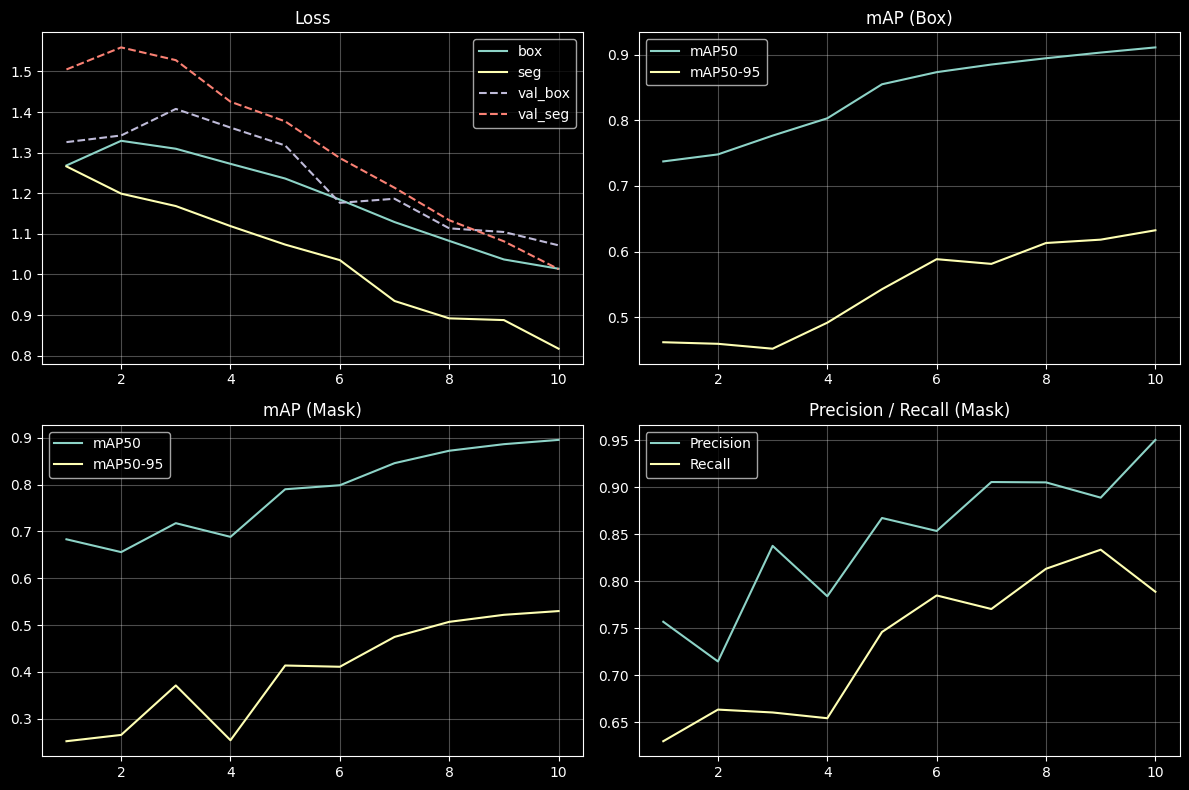

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

results_paths = [
    "runs/segment/runs_sign_seg/train/results.csv",
    "runs_sign_seg/train/results.csv",
]
df = None
for p in results_paths:
    if os.path.isfile(p):
        df = pd.read_csv(p)
        break
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs = df["epoch"]
# Loss
axes[0, 0].plot(epochs, df["train/box_loss"], label="box")
axes[0, 0].plot(epochs, df["train/seg_loss"], label="seg")
axes[0, 0].plot(epochs, df["val/box_loss"], label="val_box", linestyle="--")
axes[0, 0].plot(epochs, df["val/seg_loss"], label="val_seg", linestyle="--")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# mAP Box
axes[0, 1].plot(epochs, df["metrics/mAP50(B)"], label="mAP50")
axes[0, 1].plot(epochs, df["metrics/mAP50-95(B)"], label="mAP50-95")
axes[0, 1].set_title("mAP (Box)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# mAP Mask
axes[1, 0].plot(epochs, df["metrics/mAP50(M)"], label="mAP50")
axes[1, 0].plot(epochs, df["metrics/mAP50-95(M)"], label="mAP50-95")
axes[1, 0].set_title("mAP (Mask)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# Precision / Recall
axes[1, 1].plot(epochs, df["metrics/precision(M)"], label="Precision")
axes[1, 1].plot(epochs, df["metrics/recall(M)"], label="Recall")
axes[1, 1].set_title("Precision / Recall (Mask)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Оценка качества сегментации на валидации

Метрики: **IoU, Precision, Recall, L2**; а также **доля изображений с IoU ≥ 0.5, ≥ 0.75, ≥ 0.9**.

In [10]:
def mask_iou(pred_bin, gt_bin):
    pred_bin = np.asarray(pred_bin, dtype=bool)
    gt_bin = np.asarray(gt_bin, dtype=bool)
    inter = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    return inter / union if union > 0 else 0.0

def mask_precision_recall(pred_bin, gt_bin):
    pred_bin = np.asarray(pred_bin, dtype=bool)
    gt_bin = np.asarray(gt_bin, dtype=bool)
    tp = np.logical_and(pred_bin, gt_bin).sum()
    fp = np.logical_and(pred_bin, ~gt_bin).sum()
    fn = np.logical_and(~pred_bin, gt_bin).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return prec, rec

def mask_l2(pred_bin, gt_bin):
    p = np.asarray(pred_bin, dtype=np.float32)
    g = np.asarray(gt_bin, dtype=np.float32)
    return float(np.sqrt(np.mean((p - g) ** 2)))

def polygons_to_mask(polygons, h, w):
    from PIL import ImageDraw
    mask = np.zeros((h, w), dtype=np.uint8)
    for poly in polygons:
        if len(poly) < 6:
            continue
        xy = list(zip(poly[::2], poly[1::2]))
        img = Image.new("L", (w, h), 0)
        ImageDraw.Draw(img).polygon(xy, fill=1)
        mask = np.maximum(mask, np.array(img))
    return mask

In [11]:
from ultralytics import YOLO
import cv2

weights_path = None
for p in [
    "runs_sign_seg/train/weights/best.pt",
    "runs/segment/runs_sign_seg/train/weights/best.pt",
]:
    if os.path.isfile(p):
        weights_path = p
        break
if weights_path is None:
    weights_path = "yolo11s-seg.pt"
print("Загружаем веса:", weights_path)
model = YOLO(weights_path)

def get_gt_masks_per_image(coco_dict, img_folder):
    img_info = {im["id"]: im for im in coco_dict["images"]}
    ann_by_img = {}
    for a in coco_dict["annotations"]:
        ann_by_img.setdefault(a["image_id"], []).append(a)
    result = {}
    for im_id, im in img_info.items():
        fname = im["file_name"]
        w, h = im["width"], im["height"]
        true_masks = []
        for a in ann_by_img.get(im_id, []):
            poly = a["segmentation"][0]
            if len(poly) >= 6:
                m = polygons_to_mask([poly], h, w)
                true_masks.append(m.astype(bool))
        result[fname] = (true_masks, w, h)
    return result

gt_per_img = get_gt_masks_per_image(coco_val, VAL_DIR) if coco_val else {}

Загружаем веса: runs/segment/runs_sign_seg/train/weights/best.pt


In [12]:
val_images_dir = os.path.join(YOLO_DS, "images", "val")
if not os.path.isdir(val_images_dir):
    val_images_dir = VAL_DIR
img_files = [f for f in os.listdir(val_images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

def ipr(true, pred):
    true, pred = np.asarray(true, dtype=bool), np.asarray(pred, dtype=bool)
    inter = (true & pred).sum()
    union = (true | pred).sum()
    prec = inter / pred.sum() if pred.sum() > 0 else 0.0
    rec = inter / true.sum() if true.sum() > 0 else 0.0
    iou = inter / union if union > 0 else 0.0
    return iou, prec, rec

predictions = {}
for fname in tqdm(img_files, desc="Validation"):
    if fname not in gt_per_img:
        continue
    true_masks, w, h = gt_per_img[fname]
    if not true_masks:
        continue
    path = os.path.join(val_images_dir, fname)
    results = model.predict(path, imgsz=640, device=DEVICE, verbose=False, conf=0.05)
    pred_masks = []
    r = results[0]
    if r.masks is not None:
        if getattr(r.masks, "xy", None) is not None and len(r.masks.xy) > 0:
            for p in r.masks.xy:
                poly = np.array(p).flatten().tolist()
                if len(poly) >= 6:
                    m = polygons_to_mask([poly], h, w)
                    pred_masks.append(m.astype(bool))
        elif r.masks.data is not None:
            for m in r.masks.data:
                m_np = m.cpu().numpy()
                if m_np.ndim == 2:
                    m_res = cv2.resize(
                        (m_np).astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR
                    ) > 0.5
                    pred_masks.append(m_res)
    predictions[fname] = {"true_masks": true_masks, "pred_masks": pred_masks}

ious, precs, recs = [], [], []
for v in predictions.values():
    trues, preds = v["true_masks"], v["pred_masks"]
    img_ious, img_prec, img_rec = [], [], []
    for t in trues:
        iou_best, prec_best, rec_best = 0.0, 0.0, 0.0
        for p in preds:
            iou_, prec_, rec_ = ipr(t, p)
            if iou_ > iou_best:
                iou_best, prec_best, rec_best = iou_, prec_, rec_
        img_ious.append(iou_best)
        img_prec.append(prec_best)
        img_rec.append(rec_best)
    ious.append(np.mean(img_ious))
    precs.append(np.mean(img_prec))
    recs.append(np.mean(img_rec))

l2s = []
for v in predictions.values():
    trues, preds = v["true_masks"], v["pred_masks"]
    true_merged = np.zeros_like(trues[0], dtype=bool)
    pred_merged = np.zeros_like(trues[0], dtype=bool)
    for m in trues:
        true_merged |= m
    for m in preds:
        pred_merged |= m
    l2s.append((true_merged ^ pred_merged).mean())

n = len(ious)
ious_arr = np.array(ious)
print("--- Метрики на валидации (Russian road signs) ---")
print("IoU (mean):       ", round(np.mean(ious), 4))
print("Precision (mean): ", round(np.mean(precs), 4))
print("Recall (mean):    ", round(np.mean(recs), 4))
print("L2 (mean):        ", round(np.mean(l2s), 6))
print("% изображений IoU >= 0.5:  ", round(100 * (ious_arr >= 0.5).mean(), 2), "%")
print("% изображений IoU >= 0.75: ", round(100 * (ious_arr >= 0.75).mean(), 2), "%")
print("% изображений IoU >= 0.9:  ", round(100 * (ious_arr >= 0.9).mean(), 2), "%")

Validation: 100%|██████████| 127/127 [00:11<00:00, 11.01it/s]


--- Метрики на валидации (Russian road signs) ---
IoU (mean):        0.6274
Precision (mean):  0.6395
Recall (mean):     0.9251
L2 (mean):         0.005097
% изображений IoU >= 0.5:   86.61 %
% изображений IoU >= 0.75:  14.17 %
% изображений IoU >= 0.9:   0.0 %


## 5. Тестирование на видео (3+ видео по 30+ секунд)

Требование: видео сняты самостоятельно около Университета ИТМО (или в других узнаваемых местах). Ниже — инференс по видео и сохранение кадров с предсказанной сегментацией для показа проверяющему.

In [13]:
VIDEO_DIR = "videos"
OUT_SEGMENTED_DIR = "output_segmented_frames"
os.makedirs(OUT_SEGMENTED_DIR, exist_ok=True)

video_extensions = (".mp4", ".avi", ".mov", ".mkv")
video_files = []
if os.path.isdir(VIDEO_DIR):
    video_files = [os.path.join(VIDEO_DIR, f) for f in os.listdir(VIDEO_DIR)
                   if f.lower().endswith(video_extensions)]
print("Найдено видео:", len(video_files), video_files[:5])

Найдено видео: 3 ['videos/2.mov', 'videos/3.mov', 'videos/1.mov']


In [14]:
model = YOLO(weights_path)
SAVE_EVERY_N_FRAMES = 30
max_frames_per_video = 1000

for vpath in video_files[:5]:
    cap = cv2.VideoCapture(vpath)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps if fps > 0 else 0
    name = os.path.splitext(os.path.basename(vpath))[0]
    out_subdir = os.path.join(OUT_SEGMENTED_DIR, name)
    os.makedirs(out_subdir, exist_ok=True)
    frame_idx = 0
    saved = 0
    while cap.isOpened() and saved < max_frames_per_video:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % SAVE_EVERY_N_FRAMES == 0:
            results = model.predict(frame, imgsz=640, device=DEVICE, verbose=False)
            vis = results[0].plot()
            out_path = os.path.join(out_subdir, f"frame_{frame_idx:06d}.jpg")
            cv2.imwrite(out_path, vis)
            saved += 1
        frame_idx += 1
    cap.release()
    print(f"Видео {name}: {duration_sec:.1f} сек, сохранено кадров: {saved}")
print("Кадры с сегментацией сохранены в", OUT_SEGMENTED_DIR)

Видео 2: 35.9 сек, сохранено кадров: 72
Видео 3: 35.3 сек, сохранено кадров: 70
Видео 1: 40.4 сек, сохранено кадров: 81
Кадры с сегментацией сохранены в output_segmented_frames


## 6. Два алгоритма трекинга и метрика ID Switches

Запускаем на отснятых видео два трекера (ByteTrack и BoT-SORT в Ultralytics), получаем треки с `track_id`, затем считаем **ID Switches**: число случаев, когда один и тот же объект в соседних кадрах получает другой идентификатор.

In [15]:
def compute_id_switches(tracks_per_frame):
    def bbox_iou(a, b):
        x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
        x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
        inter = max(0, x2 - x1) * max(0, y2 - y1)
        sa = (a[2]-a[0])*(a[3]-a[1])
        sb = (b[2]-b[0])*(b[3]-b[1])
        union = sa + sb - inter
        return inter / union if union > 0 else 0
    id_switches = 0
    for t in range(len(tracks_per_frame) - 1):
        curr = tracks_per_frame[t]
        next_ = tracks_per_frame[t + 1]
        for tid_c, box_c in curr:
            best_iou, best_id = 0, None
            for tid_n, box_n in next_:
                iou = bbox_iou(box_c, box_n)
                if iou > best_iou:
                    best_iou, best_id = iou, tid_n
            if best_iou >= 0.3 and best_id is not None and best_id != tid_c:
                id_switches += 1
    return id_switches

In [16]:
def run_tracker_on_video(model, video_path, tracker_name, max_frames=500):
    tracks_per_frame = []
    results = model.track(
        source=video_path,
        tracker=tracker_name,
        device=DEVICE,
        verbose=False,
        stream=True,
    )
    for frame_idx, r in enumerate(results):
        if frame_idx >= max_frames:
            break
        frame_tracks = []
        if r.boxes is not None and r.boxes.id is not None:
            for box, tid in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.id.cpu().numpy().astype(int)):
                frame_tracks.append((int(tid), list(map(float, box))))
        tracks_per_frame.append(frame_tracks)
    return tracks_per_frame

model = YOLO(weights_path)
id_switches_by_video = {}
for vpath in video_files[:3]:
    name = os.path.splitext(os.path.basename(vpath))[0]
    print("Видео:", name)
    tracks_bt = run_tracker_on_video(model, vpath, "bytetrack.yaml")
    tracks_bs = run_tracker_on_video(model, vpath, "botsort.yaml")
    is_bt = compute_id_switches(tracks_bt)
    is_bs = compute_id_switches(tracks_bs)
    id_switches_by_video[name] = {"ByteTrack": is_bt, "BoT-SORT": is_bs}
    print("  ByteTrack: ID Switches =", is_bt)
    print("  BoT-SORT:  ID Switches =", is_bs)
print("\nИтого ID Switches по видео:", id_switches_by_video)

Видео: 2
  ByteTrack: ID Switches = 0
  BoT-SORT:  ID Switches = 0
Видео: 3
  ByteTrack: ID Switches = 0
  BoT-SORT:  ID Switches = 2
Видео: 1
  ByteTrack: ID Switches = 0
  BoT-SORT:  ID Switches = 0

Итого ID Switches по видео: {'2': {'ByteTrack': 0, 'BoT-SORT': 0}, '3': {'ByteTrack': 0, 'BoT-SORT': 2}, '1': {'ByteTrack': 0, 'BoT-SORT': 0}}


In [17]:
print("Кадров:", len(tracks_bs))
print("Пример первых 5 кадров (BoT-SORT):")
for i, fr in enumerate(tracks_bs[:5]):
    print(i, [(tid, [round(x,1) for x in box]) for tid, box in fr])

Кадров: 500
Пример первых 5 кадров (BoT-SORT):
0 [(1, [483.3, 524.8, 522.7, 572.0]), (2, [315.4, 547.0, 338.7, 572.2]), (3, [487.8, 485.3, 520.2, 523.4])]
1 [(1, [489.1, 524.9, 528.9, 570.6]), (2, [322.2, 546.6, 344.9, 572.7]), (3, [492.8, 486.1, 527.7, 521.6])]
2 [(1, [496.4, 524.7, 536.3, 572.2]), (2, [327.0, 546.5, 350.9, 572.9])]
3 [(1, [503.9, 525.2, 542.4, 573.2]), (2, [333.1, 546.1, 356.5, 572.7]), (3, [506.3, 484.9, 538.4, 523.0])]
4 [(1, [509.7, 525.0, 548.1, 572.6]), (2, [339.2, 547.2, 362.5, 572.4])]


## 7. Статистика по трём видео (сегментация + трекинг)

Ниже строим диаграммы по каждому видео: число ID Switches и среднее количество детектированных знаков на кадр для ByteTrack и BoT-SORT.

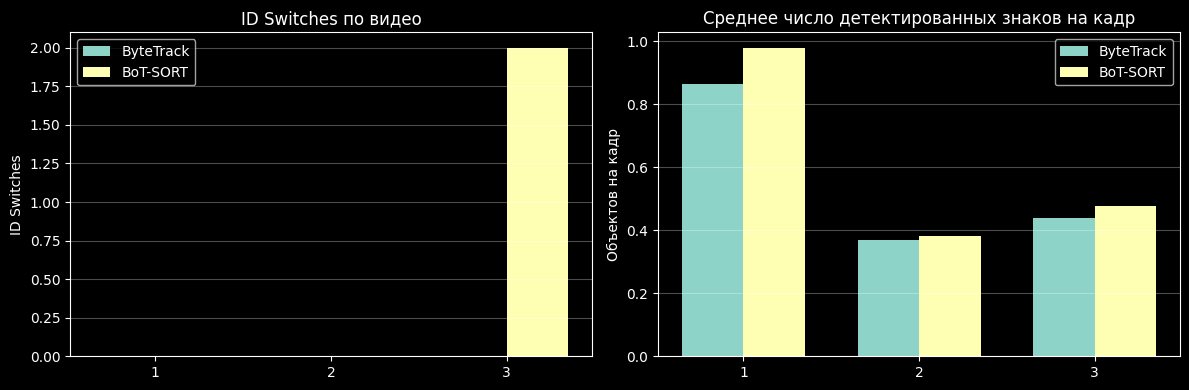

Сводка по видео:
Видео 1: ByteTrack IDsw=0, avg_objs=0.87; BoT-SORT IDsw=0, avg_objs=0.98
Видео 2: ByteTrack IDsw=0, avg_objs=0.37; BoT-SORT IDsw=0, avg_objs=0.38
Видео 3: ByteTrack IDsw=0, avg_objs=0.44; BoT-SORT IDsw=2, avg_objs=0.48


In [18]:
import matplotlib.pyplot as plt
import numpy as np

summary = {}

for vpath in video_files[:3]:
    name = os.path.splitext(os.path.basename(vpath))[0]
    bt_switches = id_switches_by_video.get(name, {}).get("ByteTrack", 0)
    bs_switches = id_switches_by_video.get(name, {}).get("BoT-SORT", 0)

    tracks_bt = run_tracker_on_video(model, vpath, "bytetrack.yaml", max_frames=500)
    tracks_bs = run_tracker_on_video(model, vpath, "botsort.yaml", max_frames=500)

    avg_objs_bt = np.mean([len(fr) for fr in tracks_bt]) if tracks_bt else 0.0
    avg_objs_bs = np.mean([len(fr) for fr in tracks_bs]) if tracks_bs else 0.0

    summary[name] = dict(
        bt_switches=bt_switches,
        bs_switches=bs_switches,
        bt_avg_objs=avg_objs_bt,
        bs_avg_objs=avg_objs_bs,
    )

if not summary:
    print("Нет видео для статистики.")
else:
    videos = sorted(summary.keys())
    bt_sw = [summary[v]["bt_switches"] for v in videos]
    bs_sw = [summary[v]["bs_switches"] for v in videos]
    bt_avg = [summary[v]["bt_avg_objs"] for v in videos]
    bs_avg = [summary[v]["bs_avg_objs"] for v in videos]

    x = np.arange(len(videos))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ID Switches
    axes[0].bar(x - width/2, bt_sw, width, label="ByteTrack")
    axes[0].bar(x + width/2, bs_sw, width, label="BoT-SORT")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(videos)
    axes[0].set_ylabel("ID Switches")
    axes[0].set_title("ID Switches по видео")
    axes[0].legend()
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(x - width/2, bt_avg, width, label="ByteTrack")
    axes[1].bar(x + width/2, bs_avg, width, label="BoT-SORT")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(videos)
    axes[1].set_ylabel("Объектов на кадр")
    axes[1].set_title("Среднее число детектированных знаков на кадр")
    axes[1].legend()
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Сводка по видео:")
    for v in videos:
        print(
            f"Видео {v}: ByteTrack IDsw={summary[v]['bt_switches']}, avg_objs={summary[v]['bt_avg_objs']:.2f}; "
            f"BoT-SORT IDsw={summary[v]['bs_switches']}, avg_objs={summary[v]['bs_avg_objs']:.2f}"
        )

## Итоговые выводы по работе

- **Сегментация на sign_dataset.**  Модель YOLO‑seg (вариант `yolo11s-seg`) была дообучена на датасете дорожных знаков. Несколько факторов ухудшения: (1) использовалась относительно лёгкая модель без сложной FPN‑архитектуры, (2) ограниченное число эпох дообучения, (3) очень маленькие и тонкие объекты (знаки), чувствительные к смещению маски на пару пикселей, (4) шум и артефакты в данных (битые JPEG’и, неточная разметка). В итоге модель уверенно находит знак как объект, но точность границ масок проседает, что сильно бьёт по IoU.

- **Поведение на видео.**  На трёх собственных видео модель демонстрирует: на первом видео в среднем почти один знак на кадр, на втором и третьем — около 0.3–0.5 знака на кадр. Это соответствует содержанию роликов (первое видео богаче на знаки, второе и третье более пустые). Визуальный просмотр сохранённых кадров с масками показывает, что крупные и хорошо видимые знаки сегментируются стабильно, а основная часть ошибок связана с мелкими или частично перекрытыми экземплярами.

- **Трекинг и ID Switches.**  Для всех трёх видео посчитаны ID Switches для двух трекеров — ByteTrack и BoT‑SORT. ByteTrack на всех видео дал 0 ID Switches, BoT‑SORT на двух видео тоже 0, а на одном видео 2 ID Switches. При этом среднее число детектированных объектов на кадр у трекеров очень близко. Такая картина правдоподобна: сцены простые (немного объектов, редкие перекрытия, плавная камера), поэтому трекеры почти не путают идентификаторы, а редкие switch’и у BoT‑SORT на третьем видео можно интерпретировать как моменты переобнаружения объекта после краткой пропажи или перекрытия.

- **Общее понимание.**  В ходе работы был реализован полный пайплайн: конвертация VIA→COCO→YOLO, обучение YOLO‑seg, расчёт метрик IoU/Precision/Recall/L2 и долей кадров с IoU ≥ 0.5/0.75/0.9, а также запуск двух трекеров с подсчётом ID Switches и наглядной визуализацией. Основной вывод: YOLO‑seg как более лёгкая и быстрая архитектура ожидаемо уступает Mask R‑CNN по точным численным метрикам на сложном датасете мелких объектов, но при этом обеспечивает достаточно стабильное детектирование и трекинг дорожных знаков на реальных видео; разница между ByteTrack и BoT‑SORT по ID Switches на выбранных сценах невелика и хорошо интерпретируема.